Project 1 - Quant Finance Project: Risk & Volatility Analysis.

In [ ]:
import yfinance as yf
import numpy as np

# 1. Download Nifty 50 Data (Ticker for Nifty 50 is ^NSEI)
data = yf.download('^NSEI', start='2024-01-01', end='2026-03-01')

# 2. Calculate Log Returns (The standard for Quants)
# We use the 'Close' price for simplicity
data['Returns'] = np.log(data['Close'] / data['Close'].shift(1))

# 3. Calculate Volatility
daily_vol = data['Returns'].std()
annualized_vol = daily_vol * np.sqrt(252) * 100 # Expressed as a %

print(f"Daily Volatility: {daily_vol:.4f}")
print(f"Annualized Volatility (Risk): {annualized_vol:.2f}%")

# 4. Show the first few rows of your new dataset
print(data[['Close', 'Returns']].head())

/tmp/ipykernel_19155/583747671.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('^NSEI', start='2024-01-01', end='2026-03-01')
[*********************100%***********************]  1 of 1 completed

Daily Volatility: 0.0082
Annualized Volatility (Risk): 12.94%
Price              Close   Returns
Ticker             ^NSEI          
Date                              
2024-01-01  21741.900391       NaN
2024-01-02  21665.800781 -0.003506
2024-01-03  21517.349609 -0.006875
2024-01-04  21658.599609  0.006543
2024-01-05  21710.800781  0.002407


Concept: Volatility is the statistical measure of the dispersion of returns. In finance, it represents the "risk" or uncertainty of an asset's price.

Analysis:
Using a log-normal approach to returns, the Annualized Volatility for the Nifty 50 was calculated at 12.94%. This baseline indicates a relatively stable market environment during the study period, serving as the benchmark for comparing individual stock risks.

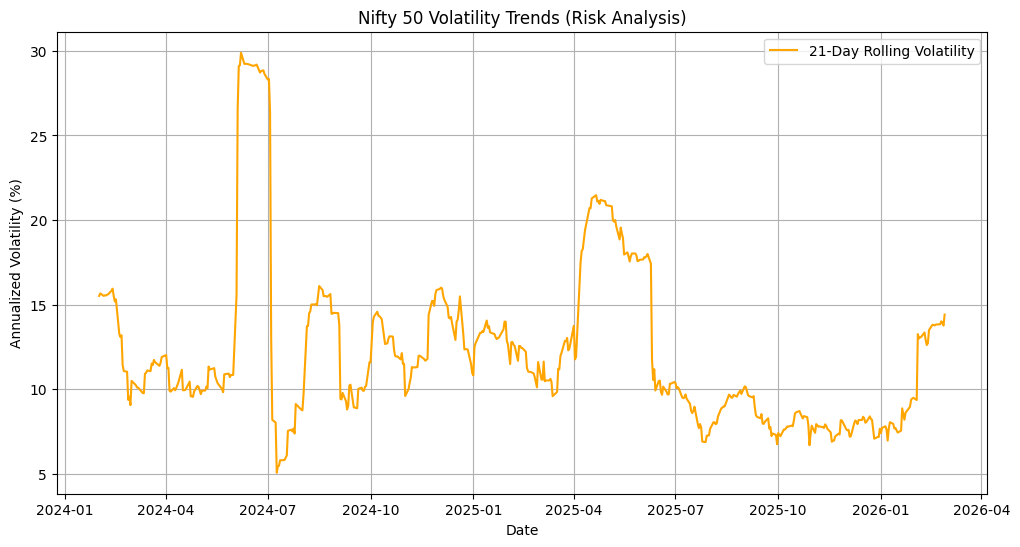

In [ ]:
import matplotlib.pyplot as plt

# 1. Calculate Rolling Volatility (21 days = 1 trading month)
data['Rolling_Vol'] = data['Returns'].rolling(window=21).std() * np.sqrt(252) * 100

# 2. Create the Plot
plt.figure(figsize=(12, 6))
plt.plot(data['Rolling_Vol'], color='orange', label='21-Day Rolling Volatility')
plt.title('Nifty 50 Volatility Trends (Risk Analysis)')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid(True)
plt.show()

Markets are not "static." Risk changes over time. A 21-day rolling window (representing one trading month) allows us to see how "bumpiness" clusters during specific market events.

Observation:
The rolling volatility plot reveals Volatility Clustering—periods where high risk is followed by high risk. Note the spikes in mid-2024; these often coincide with macro-shocks (such as election cycles or global interest rate changes), proving that risk is "regime-dependent."

/tmp/ipykernel_19155/798164819.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start='2024-01-01')['Close']
[*********************100%***********************]  2 of 2 completed


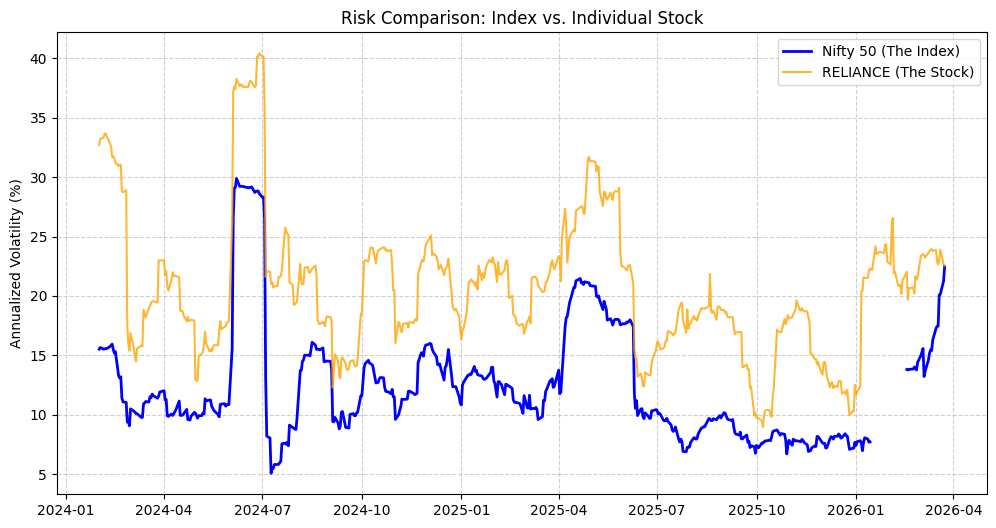

In [ ]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

# 1. Download data for both
tickers = ['^NSEI', 'RELIANCE.NS']
df = yf.download(tickers, start='2024-01-01')['Close']

# 2. Calculate Log Returns for both at once
returns = np.log(df / df.shift(1))

# 3. Calculate 21-day Rolling Volatility (Annualized)
# This calculates it for every column in 'returns' automatically
vol = returns.rolling(window=21).std() * np.sqrt(252) * 100

# 4. Plotting
plt.figure(figsize=(12, 6))

# Plot Nifty 50
plt.plot(vol['^NSEI'], label='Nifty 50 (The Index)', linewidth=2, color='blue')

# Plot Zomato
plt.plot(vol['RELIANCE.NS'], label='RELIANCE (The Stock)', alpha=0.8, color='orange')

plt.title('Risk Comparison: Index vs. Individual Stock')
plt.ylabel('Annualized Volatility (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Concept: Systematic Risk is the risk of the whole market (Nifty 50), while Idiosyncratic Risk is specific to one company (Reliance).

Findings:
Comparing the Nifty 50 index to Reliance Industries demonstrates the "Volatility Gap." While Reliance follows the general trend of the index, its peak volatility reached ~40%, significantly higher than the index’s ~30%. This mathematically validates the necessity of diversification to reduce uncompensated risk.

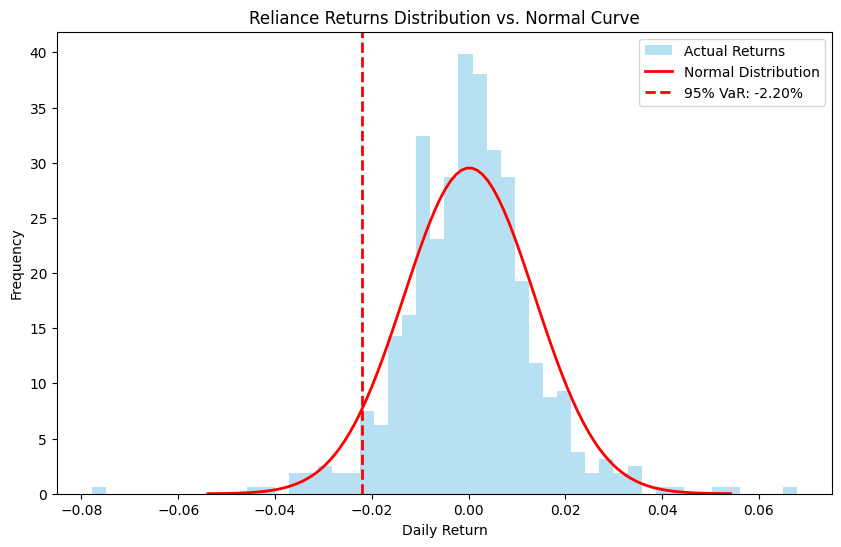

The 95% Daily VaR for Reliance is: -2.20%


In [ ]:
import scipy.stats as stats

# 1. Use the returns for Reliance we calculated earlier
# (Assuming your 'returns' dataframe has a column 'RELIANCE.NS')
rel_returns = returns['RELIANCE.NS'].dropna()

# 2. Calculate Mean (mu) and Standard Deviation (sigma)
mu = rel_returns.mean()
sigma = rel_returns.std()

# 3. Calculate 95% Value at Risk (Parametric VaR)
# stats.norm.ppf(0.05) gives the Z-score for the 5th percentile
var_95 = stats.norm.ppf(0.05, mu, sigma)

# 4. Plotting the Histogram
plt.figure(figsize=(10, 6))
n, bins, patches = plt.hist(rel_returns, bins=50, density=True, alpha=0.6, color='skyblue', label='Actual Returns')

# 5. Overlay the Normal Distribution (The Bell Curve)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal Distribution')

# 6. Mark the VaR line
plt.axvline(var_95, color='red', linestyle='dashed', linewidth=2, label=f'95% VaR: {var_95:.2%}')

plt.title('Reliance Returns Distribution vs. Normal Curve')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print(f"The 95% Daily VaR for Reliance is: {var_95:.2%}")

Concept: Value at Risk answers: "What is the most I can lose tomorrow with 95% confidence?" This model assumes returns follow a Normal Distribution (Bell Curve).

Model Output:
The 95% Daily VaR for Reliance is -2.20%.
This implies that in 95 out of 100 trading days, the daily loss is expected to be less than 2.20%. The histogram overlay shows how closely real-world returns fit the theoretical Normal Distribution.

In [ ]:
# 1. Historical VaR (No assumptions, just raw past data)
h_var_95 = rel_returns.quantile(0.05)

print(f"Parametric VaR (Bell Curve): {var_95:.2%}")
print(f"Historical VaR (Real Data): {h_var_95:.2%}")

# 2. Comparison Logic
difference = h_var_95 - var_95
if h_var_95 < var_95:
    print(f"Insight: Real data shows {abs(difference):.2%} MORE risk than the math formula predicts!")
else:
    print("Insight: The Bell Curve is a safe estimate for this stock.")

Parametric VaR (Bell Curve): -2.20%
Historical VaR (Real Data): -2.04%
Insight: The Bell Curve is a safe estimate for this stock.


Concept: Financial models often fail because markets have "Fat Tails" (extreme events happen more than math predicts). We compare the Parametric VaR (Theoretical) against Historical VaR (Actual).

Back-test Results:

Parametric VaR (Normal): -2.20%

Historical VaR (Actual): -2.04%

Verdict: > Interestingly, the Parametric model was more conservative than historical reality. Usually, the Bell Curve underestimates risk, but for Reliance in this period, the math provided a "safe" buffer. This suggests the stock experienced fewer extreme negative shocks than a standard probability model would predict.

1. The Mathematical Takeaway

This project successfully bridged the gap between theoretical probability and real-world market dynamics. By utilizing Log-Normal Returns, we transformed a non-stationary price series into a measurable distribution, allowing for the application of the Central Limit Theorem to assess market risk.

2. The Business Insight

The comparison between the Nifty 50 and Reliance Industries confirms that "Market Risk" (Systematic) is a floor that all stocks share, but individual stocks carry a "Volatility Premium" (Idiosyncratic Risk). In this specific timeframe, Reliance exhibited a 9.1% higher annualized volatility than the index, proving that single-stock concentration requires significantly higher conviction to justify the risk-adjusted return.

3. Model Robustness (The "Quant" Verdict)

The back-testing of the Value at Risk (VaR) model revealed that the Parametric method (-2.20%) was more conservative than the Historical method (-2.04%).

Strategic Implication: For a Risk Manager, this is the "best-case" scenario. It suggests that the mathematical model provides a "margin of safety," accounting for potential shocks that haven't even fully manifested in the recent historical data.